# Retail Sales Exploratory Data Analysis (EDA)
## Level 1 — Task 1

In [24]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/OIBSIP/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [17]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types null values:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:",df.duplicated().sum())

Dataset shape: (1000, 9)

Column names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data types null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB

Miss

## Initial Data Inspection

The dataset contains 1,000 retail transactions and 9 columns. There are no missing values or duplicate rows, indicating that the dataset is clean and ready for analysis. Most numerical columns have the correct data type. However, the `Date` column is stored as text and will be converted to datetime format for time-series analysis.

In [18]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Check the uploaded data type
print(df.dtypes)

# Descriptive statistics for numerical columns
df.describe()

numerical_columns = ["Age", "Quantity","Price per Unit", "Total Amount"]

statistics = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Standard Deviation": df[numerical_columns].std()
})

statistics

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## Descriptive Statistics

The average customer age is approximately 41 years, while the most common age is 43. Customers purchase an average of 2.5 items per transaction.

The mean price per unit (179.89) and mean total transaction amount (456.00) are much higher than their median values (50 and 135). This suggests that a small number of high-value purchases may be increasing the average sales value.

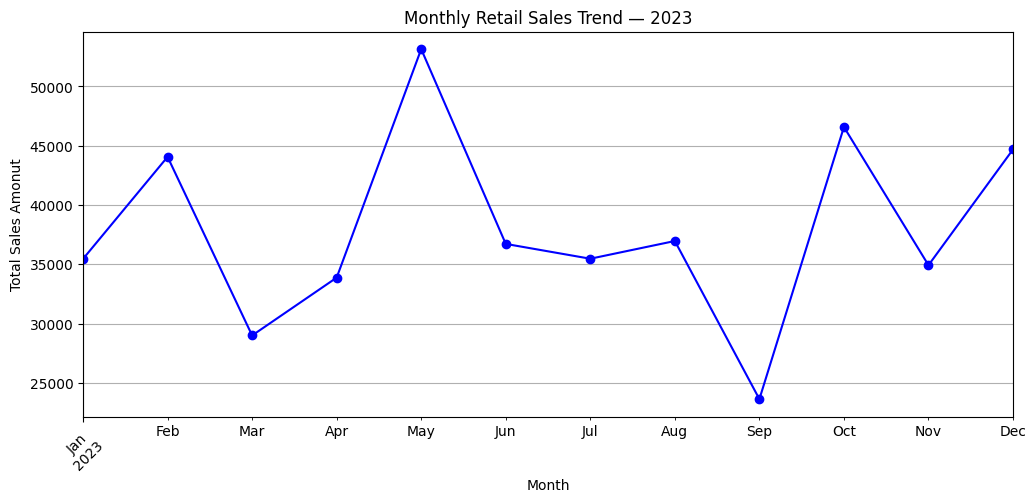

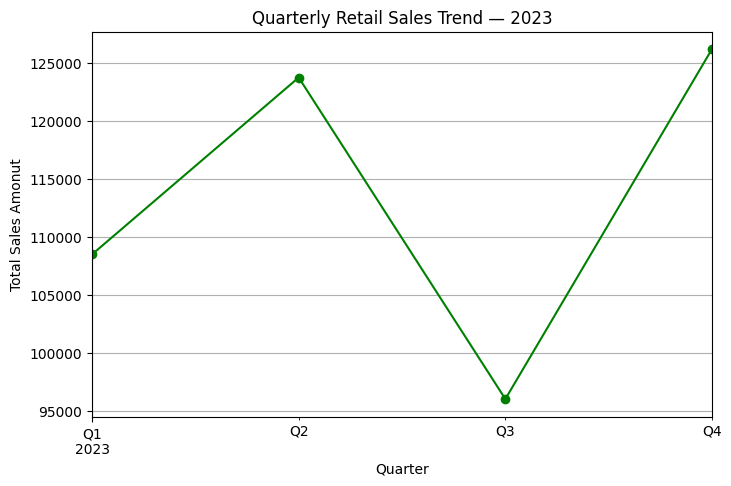

In [19]:
# Keep only complete 2023 data for time - series analysis
df_2023 = df[df["Date"].dt.year == 2023].copy()

# Create Month and Quarter columns from Date
df_2023["Month"] = df_2023["Date"].dt.to_period("M")
df_2023["Quarter"] = df_2023["Date"].dt.to_period("Q")

# Calculate total sales by month and quarter
monthly_sales = df_2023.groupby("Month")["Total Amount"].sum()
quarterly_sales = df_2023.groupby("Quarter")["Total Amount"].sum()

# Monthly sales trend chart
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker= "o", color="blue")
plt.title("Monthly Retail Sales Trend — 2023")
plt.xlabel("Month")
plt.ylabel("Total Sales Amonut")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Quarterly sales trend chart
plt.figure(figsize=(8, 5))
quarterly_sales.plot(kind="line", marker= "o", color="green")
plt.title("Quarterly Retail Sales Trend — 2023")
plt.xlabel("Quarter")
plt.ylabel("Total Sales Amonut")
plt.grid(True)
plt.show()

## Sales Trend Insights

Monthly sales were highest in May 2023, exceeding 50,000. Sales were lowest in September 2023, at approximately 24,000. Quarterly sales were strongest in Quarter 4, followed closely by Quarter 2. Therefore, the business should prepare sufficient inventory and promotional campaigns before high-performing periods, especially Q2 and Q4.

January 2024 was excluded because it contains incomplete transaction data and would distort the comparison.

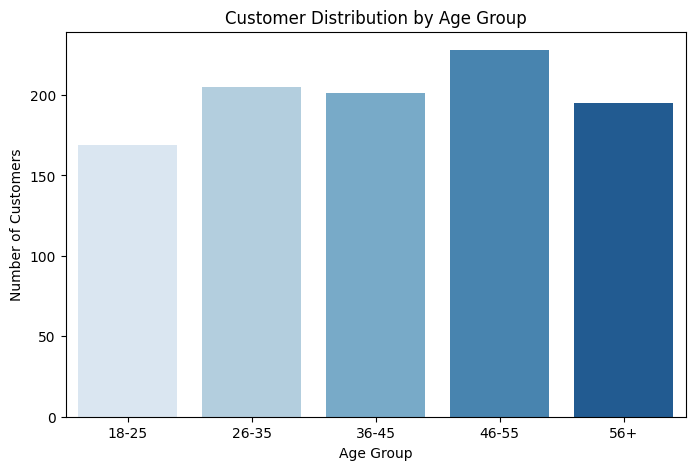

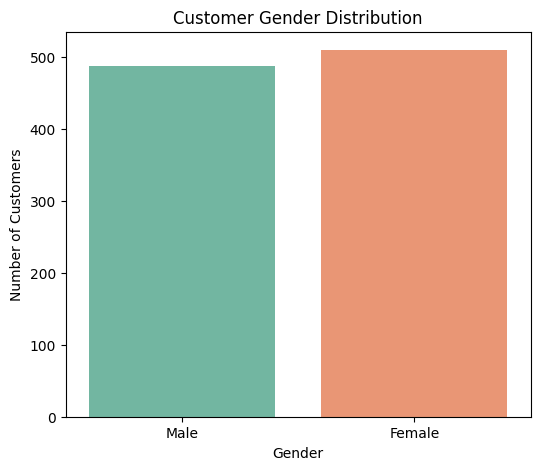

In [25]:
# Create customer age groups
df_2023["Age Group"] = pd.cut(
    df_2023["Age"],
    bins=[0,25,35,45,55,100],
    labels=["18-25","26-35","36-45","46-55","56+"]
)

# Age-group distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df_2023, x="Age Group",hue="Age Group", palette="Blues", legend=False)
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

# Gender distribution
plt.figure(figsize=(6,5))
sns.countplot(data=df_2023, x="Gender",hue="Gender", palette="Set2", legend=False)
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

## Customer Demographics Insights

Customers aged 46–55 form the largest customer group, while customers aged 18–25 form the smallest group. Marketing campaigns and product recommendations can be tailored especially toward the 46–55 age group.

The gender distribution is nearly balanced, with slightly more female customers than male customers. Therefore, the business should use inclusive marketing rather than focusing only on one gender.

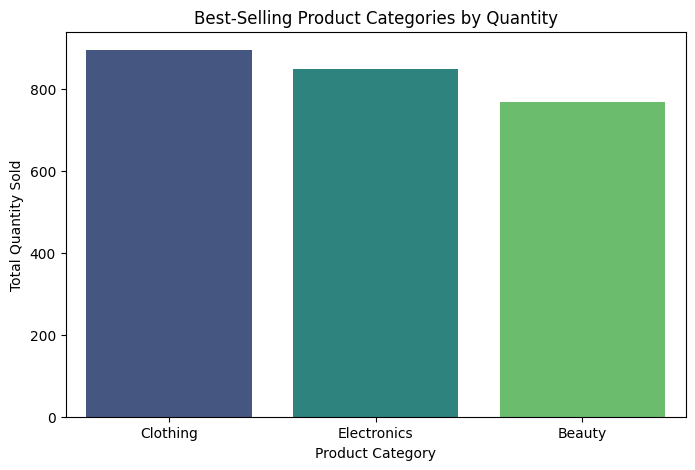

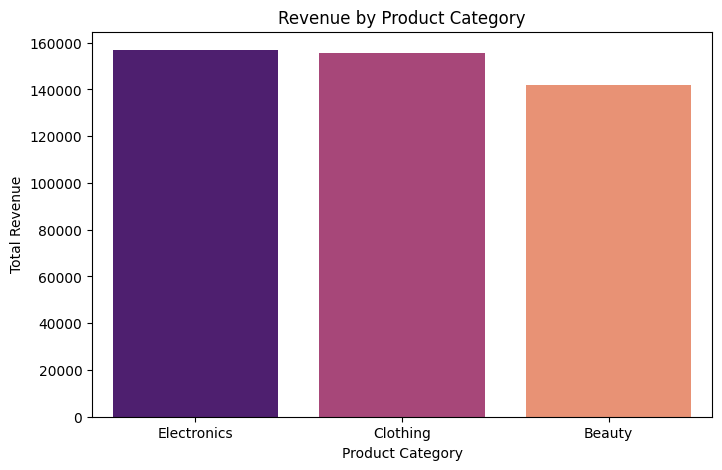

,Total Quantity Sold,Total Revenue
Product Category,,
Beauty,768,142015
Clothing,894,155580
Electronics,848,156875


In [26]:

# Total quantity sold by product category
category_quantity = (
    df_2023.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)

)

plt.figure(figsize=(8,5))
sns.barplot(x=category_quantity.index, y=category_quantity.values, palette="viridis", hue=category_quantity.index, legend=False)
plt.title("Best-Selling Product Categories by Quantity")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.show()

# Revenue by product category
category_revenue = (
    df_2023.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette="magma", hue=category_revenue.index, legend=False)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

# Show exact totals in a table
category_summary = pd.DataFrame({
    "Total Quantity Sold" : category_quantity,
    "Total Revenue": category_revenue
})

category_summary

## Product Category Insights

Clothing has the highest total quantity sold, followed by Electronics and Beauty. However, Electronics generates the highest total revenue, while Beauty generates the lowest revenue.

This suggests that Electronics may have a higher average selling price. The business should maintain inventory for Clothing because of its high demand, while promoting Electronics because it generates strong revenue.

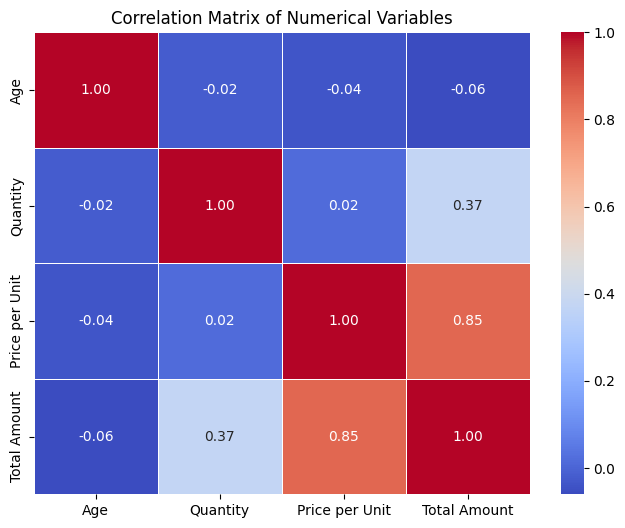

In [22]:
# Select meaningful numerical columns
numeric_data = df_2023[["Age","Quantity","Price per Unit","Total Amount"]]

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_data.corr(),
    annot= True,
    cmap="coolwarm",
    fmt =".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

## Correlation Insights

Price per Unit has a strong positive correlation (0.85) with Total Amount. This means higher-priced products tend to generate higher transaction revenue.

Quantity has a moderate positive correlation (0.37) with Total Amount, showing that purchasing more items also increases revenue. Age has almost no correlation with Total Amount, so customer age alone is not a strong predictor of transaction value.

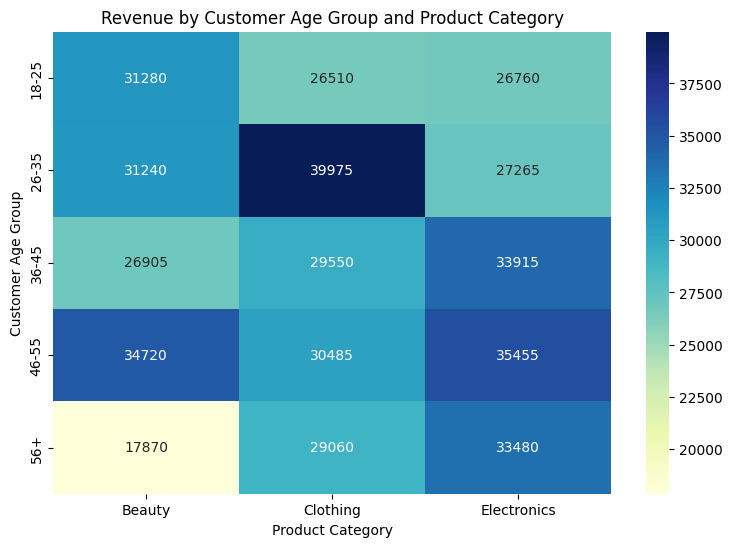

In [23]:
# Revenue by age group and product category
age_category_revenue = pd.pivot_table(
    df_2023,
    values="Total Amount",
    index="Age Group",
    columns="Product Category",
    aggfunc="sum",
    observed=False
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    age_category_revenue,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Revenue by Customer Age Group and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Customer Age Group")
plt.show()

## Age Group and Product Category Insights

The 26–35 age group generates the highest revenue from Clothing (39,975). Customers aged 46–55 generate strong revenue from both Beauty (34,720) and Electronics (35,455).

This shows that product preferences vary across age groups. The business can target Clothing promotions toward customers aged 26–35 and promote Beauty and Electronics products to customers aged 46–55.

# Conclusion and Business Recommendations

1. Sales were strongest in Q4 and peaked in May. The business should increase stock availability and run promotional campaigns before high-sales periods.

2. Clothing had the highest quantity sold, while Electronics generated the highest revenue. The business should maintain sufficient Clothing inventory and prioritize higher-value Electronics promotions.

3. Customers aged 46–55 were the largest customer group, while the 26–35 group generated the highest Clothing revenue. Marketing campaigns should be tailored by both age group and product category.

4. Price per Unit had a strong positive relationship with Total Amount. The business can increase revenue by promoting premium products and bundles with higher average transaction value.